In [5]:
import os
from pathlib import Path
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")


In [6]:
# VISUALIZATION SETTINGS
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

# Load Preprocessed Data

In [8]:
# Direct path to Preprocessed_Data
PREPROCESSED_ROOT = Path(
    r"E:\programming languages\DJANGO PROJECT\SmartAgriVision"
    r"\SmartAgriVision\AgriVision\AI\notebooks"
    r"\Preprocessed_Data"
)


print(
    f"Path   : {PREPROCESSED_ROOT}"
)

print(
    f"Exists : {PREPROCESSED_ROOT.exists()}"
)


Path   : E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\Preprocessed_Data
Exists : True


In [9]:
# LOAD TRAIN / VALIDATION / TEST METADATA
train_df = pd.read_csv(
    PREPROCESSED_ROOT / "train_metadata.csv"
)

validation_df = pd.read_csv(
    PREPROCESSED_ROOT / "validation_metadata.csv"
)

test_df = pd.read_csv(
    PREPROCESSED_ROOT / "test_metadata.csv"
)


print("SPLIT METADATA")


print(
    f"Train      : {len(train_df):,}"
)

print(
    f"Validation : {len(validation_df):,}"
)

print(
    f"Test       : {len(test_df):,}"
)

SPLIT METADATA
Train      : 87,937
Validation : 20,564
Test       : 3,252


In [12]:

print("BASIC DATA CHECK")



# Make sure metadata file is loaded
metadata_path = (
    PREPROCESSED_ROOT
    / "image_metadata.csv"
)


if not metadata_path.exists():

    print("ERROR : image_metadata.csv was not found.")

else:

    # Load metadata if variable does not already exist
    if "image_metadata_df" not in globals():

        image_metadata_df = pd.read_csv(
            metadata_path
        )

    print("Columns:")

    print(
        image_metadata_df.columns.tolist()
    )

    print()

    print("Missing Values:")

    missing_values = (
        image_metadata_df
        .isnull()
        .sum()
        .to_frame("Missing")
    )

    display(
        missing_values
    )

    print()

    print(
        f"Total Images : "
        f"{len(image_metadata_df):,}"
    )


BASIC DATA CHECK
Columns:
['Dataset', 'Split', 'Class', 'Image_Path', 'Filename', 'Label']

Missing Values:


,Missing
Dataset,0
Split,0
Class,0
Image_Path,0
Filename,0
Label,0



Total Images : 294,695


# Dataset Distribution Visualization

In [13]:
# LOAD METADATA
if "image_metadata_df" not in globals():

    metadata_path = (
        PREPROCESSED_ROOT /
        "image_metadata.csv"
    )

    if not metadata_path.exists():
        raise FileNotFoundError(
            f"Metadata file not found:\n{metadata_path}"
        )

    image_metadata_df = pd.read_csv(
        metadata_path
    )


print("DATASET DISTRIBUTION VISUALIZATION")


print(
    f"Total Images : "
    f"{len(image_metadata_df):,}"
)

display(
    image_metadata_df.head()
)

DATASET DISTRIBUTION VISUALIZATION
Total Images : 294,695


,Dataset,Split,Class,Image_Path,Filename,Label
0,Fruits-360,Unsplit,fruits-360_100x100,Cleaned_Dataset\Fruits-360\fruits-360_100x100\...,r0_103_100.jpg,79
1,Fruits-360,Unsplit,fruits-360_100x100,Cleaned_Dataset\Fruits-360\fruits-360_100x100\...,r0_107_100.jpg,79
2,Fruits-360,Unsplit,fruits-360_100x100,Cleaned_Dataset\Fruits-360\fruits-360_100x100\...,r0_111_100.jpg,79
3,Fruits-360,Unsplit,fruits-360_100x100,Cleaned_Dataset\Fruits-360\fruits-360_100x100\...,r0_115_100.jpg,79
4,Fruits-360,Unsplit,fruits-360_100x100,Cleaned_Dataset\Fruits-360\fruits-360_100x100\...,r0_119_100.jpg,79


In [14]:
# Dataset-wise Image Count
dataset_image_count = (
    image_metadata_df
    .groupby("Dataset")
    .size()
    .reset_index(name="Images")
    .sort_values(
        "Images",
        ascending=False
    )
)

display(
    dataset_image_count
)

print(
    f"Total Images : "
    f"{dataset_image_count['Images'].sum():,}"
)

,Dataset,Images
0,Fruits-360,182942
1,New Plant Diseases,87841
3,Vegetable Dataset,20996
2,PlantDoc,2916


Total Images : 294,695


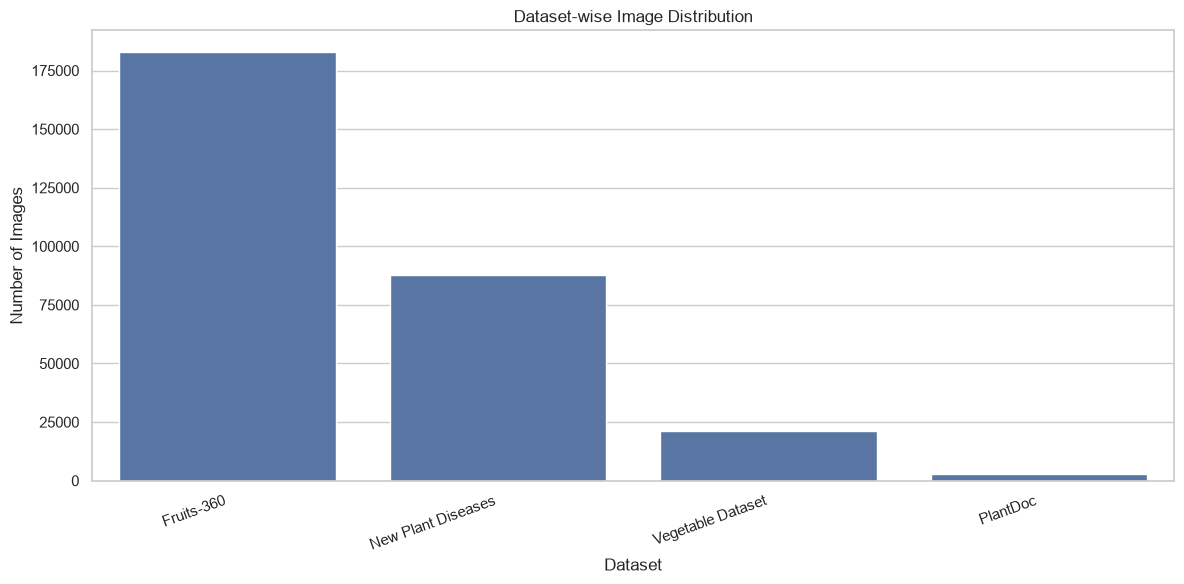

In [15]:
# Dataset Distribution Chart
plt.figure(figsize=(12, 6))

sns.barplot(
    data=dataset_image_count,
    x="Dataset",
    y="Images"
)

plt.title(
    "Dataset-wise Image Distribution"
)

plt.xlabel("Dataset")
plt.ylabel("Number of Images")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()
plt.show()

,Split,Images
0,Train,87937
1,Validation,20564
2,Test,3252


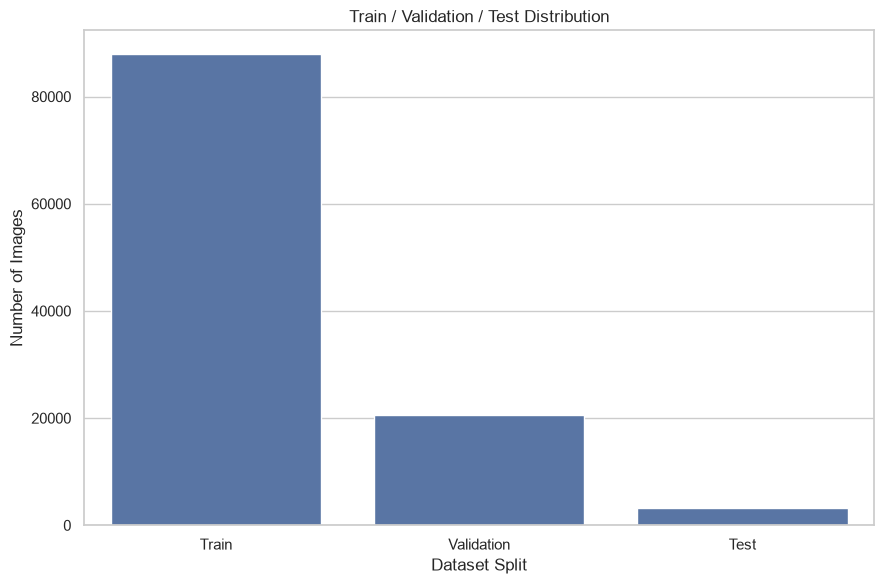

In [16]:
# Train / Validation / Test
split_files = {
    "Train": "train_metadata.csv",
    "Validation": "validation_metadata.csv",
    "Test": "test_metadata.csv"
}

split_records = []

for split_name, file_name in split_files.items():

    file_path = (
        PREPROCESSED_ROOT /
        file_name
    )

    if file_path.exists():

        split_df = pd.read_csv(
            file_path
        )

        split_records.append({
            "Split": split_name,
            "Images": len(split_df)
        })

split_distribution = pd.DataFrame(
    split_records
)

display(
    split_distribution
)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=split_distribution,
    x="Split",
    y="Images"
)

plt.title(
    "Train / Validation / Test Distribution"
)

plt.xlabel("Dataset Split")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

# Class Distribution Analysis

In [17]:
# DATASET-WISE CLASS COUNT
if "image_metadata_df" not in globals():

    image_metadata_df = pd.read_csv(
        PREPROCESSED_ROOT /
        "image_metadata.csv"
    )

required_columns = {
    "Dataset",
    "Class"
}

missing_columns = (
    required_columns
    - set(image_metadata_df.columns)
)

if missing_columns:
    raise KeyError(
        f"Missing columns: {missing_columns}"
    )

dataset_class_count = (
    image_metadata_df
    .groupby("Dataset")["Class"]
    .nunique()
    .reset_index(name="Classes")
    .sort_values(
        "Classes",
        ascending=False
    )
)

display(
    dataset_class_count
)

,Dataset,Classes
1,New Plant Diseases,38
2,PlantDoc,28
3,Vegetable Dataset,15
0,Fruits-360,1


In [18]:
# Class Image Distribution
class_distribution = (
    image_metadata_df
    .groupby(
        ["Dataset", "Class"]
    )
    .size()
    .reset_index(
        name="Images"
    )
)

print(
    f"Total Classes : "
    f"{len(class_distribution):,}"
)

display(
    class_distribution.head(20)
)

Total Classes : 82


,Dataset,Class,Images
0,Fruits-360,fruits-360_100x100,182942
1,New Plant Diseases,Apple___Apple_scab,2520
2,New Plant Diseases,Apple___Black_rot,2484
3,New Plant Diseases,Apple___Cedar_apple_rust,2200
4,New Plant Diseases,Apple___healthy,2500
5,New Plant Diseases,Blueberry___healthy,2270
6,New Plant Diseases,Cherry_(including_sour)___Powdery_mildew,2104
7,New Plant Diseases,Cherry_(including_sour)___healthy,2282
8,New Plant Diseases,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,2052
9,New Plant Diseases,Corn_(maize)___Common_rust_,2384


,Dataset,Class,Images
0,Fruits-360,fruits-360_100x100,182942
25,New Plant Diseases,Soybean___healthy,2527
1,New Plant Diseases,Apple___Apple_scab,2520
16,New Plant Diseases,Orange___Haunglongbing_(Citrus_greening),2513
4,New Plant Diseases,Apple___healthy,2500
20,New Plant Diseases,"Pepper,_bell___healthy",2485
2,New Plant Diseases,Apple___Black_rot,2484
36,New Plant Diseases,Tomato___Tomato_Yellow_Leaf_Curl_Virus,2451
22,New Plant Diseases,Potato___Late_blight,2424
21,New Plant Diseases,Potato___Early_blight,2424


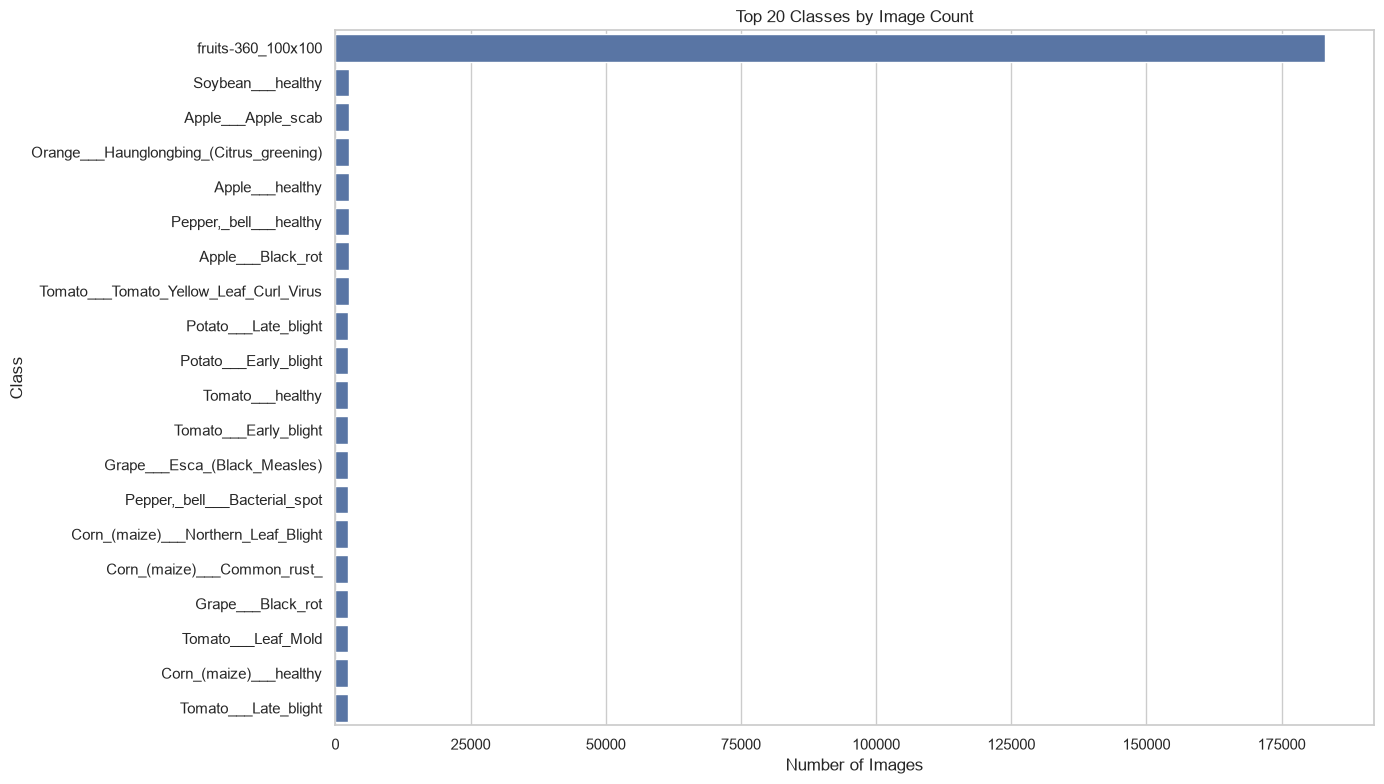

In [19]:
# Top 20 Classes
top_classes = (
    class_distribution
    .sort_values(
        "Images",
        ascending=False
    )
    .head(20)
)

display(
    top_classes
)

plt.figure(figsize=(14, 8))

sns.barplot(
    data=top_classes,
    y="Class",
    x="Images"
)

plt.title(
    "Top 20 Classes by Image Count"
)

plt.xlabel("Number of Images")
plt.ylabel("Class")

plt.tight_layout()
plt.show()

In [20]:
# Class Imbalance
class_statistics = (
    class_distribution
    .groupby("Dataset")["Images"]
    .agg(
        Minimum="min",
        Maximum="max",
        Average="mean",
        Median="median"
    )
    .reset_index()
)

display(
    class_statistics
)


,Dataset,Minimum,Maximum,Average,Median
0,Fruits-360,182942,182942,182942.000000,182942.0
1,New Plant Diseases,2052,2527,2311.605263,2300.5
2,PlantDoc,2,238,104.142857,94.5
3,Vegetable Dataset,1399,1400,1399.733333,1400.0


# Image Resolution Visualization

In [24]:
#CHECK IMAGE METADATA COLUMNS

print("IMAGE METADATA STRUCTURE CHECK")


print("Available Columns:")
print()

for i, column in enumerate(
    image_metadata_df.columns,
    start=1
):
    print(f"{i}. {column}")

print()
print("Data Shape:")
print(
    image_metadata_df.shape
)

print()
print("First 5 Records:")

display(
    image_metadata_df.head()
)


IMAGE METADATA STRUCTURE CHECK
Available Columns:

1. Dataset
2. Split
3. Class
4. Image_Path
5. Filename
6. Label

Data Shape:
(294695, 6)

First 5 Records:


,Dataset,Split,Class,Image_Path,Filename,Label
0,Fruits-360,Unsplit,fruits-360_100x100,Cleaned_Dataset\Fruits-360\fruits-360_100x100\...,r0_103_100.jpg,79
1,Fruits-360,Unsplit,fruits-360_100x100,Cleaned_Dataset\Fruits-360\fruits-360_100x100\...,r0_107_100.jpg,79
2,Fruits-360,Unsplit,fruits-360_100x100,Cleaned_Dataset\Fruits-360\fruits-360_100x100\...,r0_111_100.jpg,79
3,Fruits-360,Unsplit,fruits-360_100x100,Cleaned_Dataset\Fruits-360\fruits-360_100x100\...,r0_115_100.jpg,79
4,Fruits-360,Unsplit,fruits-360_100x100,Cleaned_Dataset\Fruits-360\fruits-360_100x100\...,r0_119_100.jpg,79


In [25]:
# IMAGE RESOLUTION SCAN
from tqdm.auto import tqdm


print("SCANNING IMAGE RESOLUTIONS")



def resolve_image_path(path_value):

    path_value = Path(path_value)

    candidates = [
        path_value,
        Path.cwd() / path_value,
        PREPROCESSED_ROOT.parent / path_value
    ]

    for candidate in candidates:

        if candidate.exists() and candidate.is_file():
            return candidate.resolve()

    return None


resolution_records = []
failed_paths = []

for _, row in tqdm(
    image_metadata_df.iterrows(),
    total=len(image_metadata_df),
    desc="Scanning Images",
    unit="image"
):

    actual_path = resolve_image_path(
        row["Image_Path"]
    )

    if actual_path is None:

        failed_paths.append(
            row["Image_Path"]
        )

        continue

    try:

        with Image.open(actual_path) as img:

            width, height = img.size

            resolution_records.append({

                "Dataset": row["Dataset"],
                "Split": row["Split"],
                "Class": row["Class"],
                "Image_Path": row["Image_Path"],
                "Filename": row["Filename"],
                "Label": row["Label"],
                "Width": width,
                "Height": height,
                "Resolution": f"{width} x {height}",
                "Mode": img.mode

            })

    except Exception:

        failed_paths.append(
            row["Image_Path"]
        )


resolution_df = pd.DataFrame(
    resolution_records
)

print()
print(
    f"Metadata Records : "
    f"{len(image_metadata_df):,}"
)

print(
    f"Successfully Scanned : "
    f"{len(resolution_df):,}"
)

print(
    f"Failed / Unreadable : "
    f"{len(failed_paths):,}"
)

display(
    resolution_df.head()
)

E:\CondaEnvs\smartagrivision\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SCANNING IMAGE RESOLUTIONS


Scanning Images: 100%|██████████| 294695/294695 [1:07:03<00:00, 73.24image/s]



Metadata Records : 294,695
Successfully Scanned : 294,695
Failed / Unreadable : 0


,Dataset,Split,Class,Image_Path,Filename,Label,Width,Height,Resolution,Mode
0,Fruits-360,Unsplit,fruits-360_100x100,Cleaned_Dataset\Fruits-360\fruits-360_100x100\...,r0_103_100.jpg,79,100,100,100 x 100,RGB
1,Fruits-360,Unsplit,fruits-360_100x100,Cleaned_Dataset\Fruits-360\fruits-360_100x100\...,r0_107_100.jpg,79,100,100,100 x 100,RGB
2,Fruits-360,Unsplit,fruits-360_100x100,Cleaned_Dataset\Fruits-360\fruits-360_100x100\...,r0_111_100.jpg,79,100,100,100 x 100,RGB
3,Fruits-360,Unsplit,fruits-360_100x100,Cleaned_Dataset\Fruits-360\fruits-360_100x100\...,r0_115_100.jpg,79,100,100,100 x 100,RGB
4,Fruits-360,Unsplit,fruits-360_100x100,Cleaned_Dataset\Fruits-360\fruits-360_100x100\...,r0_119_100.jpg,79,100,100,100 x 100,RGB


In [26]:
# RESOLUTION DISTRIBUTION
resolution_distribution = (
    resolution_df
    .groupby(
        ["Width", "Height", "Resolution"]
    )
    .size()
    .reset_index(
        name="Images"
    )
    .sort_values(
        "Images",
        ascending=False
    )
)

print(
    f"Unique Resolutions : "
    f"{len(resolution_distribution):,}"
)

display(
    resolution_distribution.head(20)
)

Unique Resolutions : 1,775


,Width,Height,Resolution,Images
0,100,100,100 x 100,182942
80,256,256,256 x 256,87841
50,224,224,224 x 224,20987
147,300,300,300 x 300,213
1594,1600,1200,1600 x 1200,56
1049,800,600,800 x 600,42
1256,1024,768,1024 x 768,34
1382,1200,1600,1200 x 1600,23
855,640,480,640 x 480,20
1133,900,675,900 x 675,19


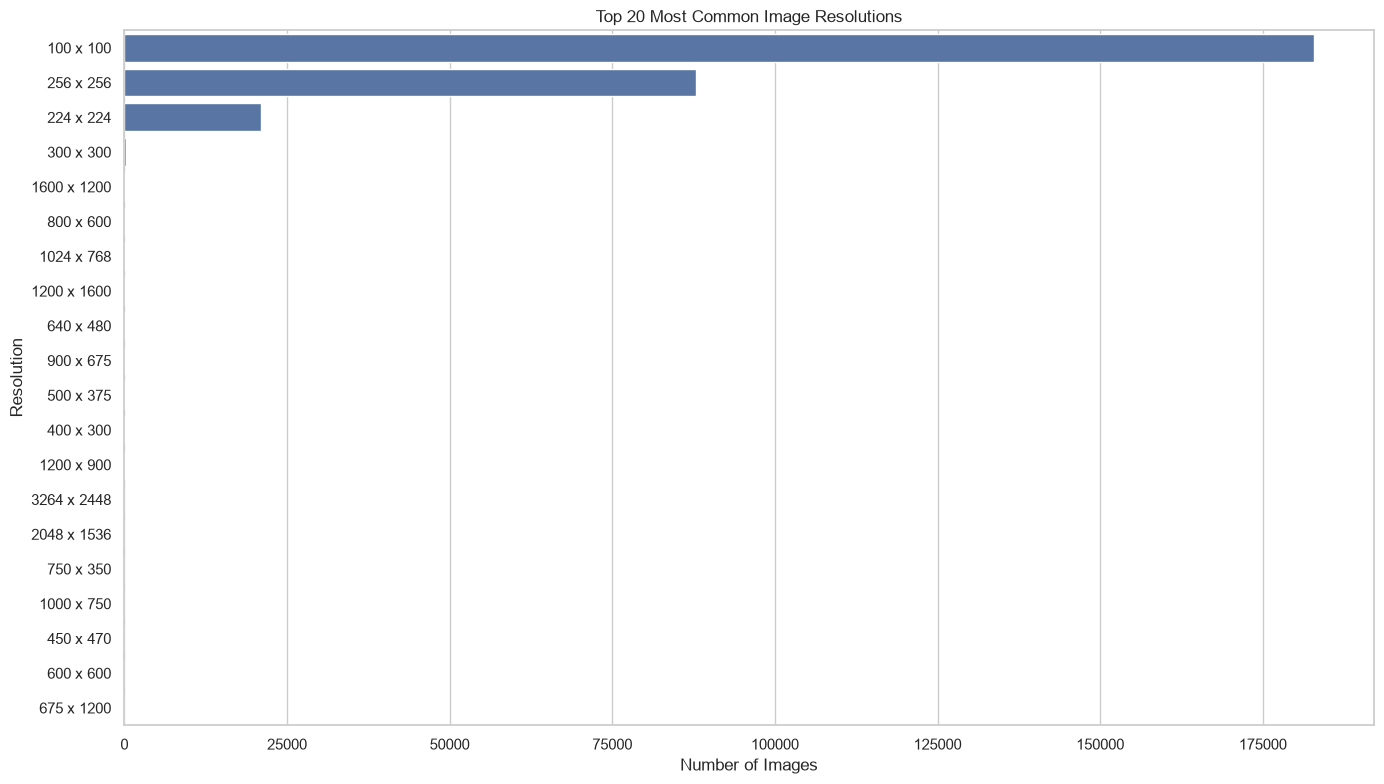

In [27]:
# MOST COMMON RESOLUTION CHART
top_resolutions = (
    resolution_distribution
    .head(20)
)

plt.figure(figsize=(14, 8))

sns.barplot(
    data=top_resolutions,
    y="Resolution",
    x="Images"
)

plt.title(
    "Top 20 Most Common Image Resolutions"
)

plt.xlabel(
    "Number of Images"
)

plt.ylabel(
    "Resolution"
)

plt.tight_layout()
plt.show()

In [28]:
# WIDTH AND HEIGHT STATISTICS
resolution_statistics = (
    resolution_df[
        [
            "Width",
            "Height"
        ]
    ]
    .describe()
)

display(
    resolution_statistics
)

print()
print(
    f"Minimum Width  : "
    f"{resolution_df['Width'].min():,} px"
)

print(
    f"Maximum Width  : "
    f"{resolution_df['Width'].max():,} px"
)

print(
    f"Minimum Height : "
    f"{resolution_df['Height'].min():,} px"
)

print(
    f"Maximum Height : "
    f"{resolution_df['Height'].max():,} px"
)

,Width,Height
count,294695.000000,294695.000000
mean,163.364071,162.260296
std,130.237873,117.804836
min,100.000000,69.000000
25%,100.000000,100.000000
50%,100.000000,100.000000
75%,256.000000,256.000000
max,6000.000000,6000.000000



Minimum Width  : 100 px
Maximum Width  : 6,000 px
Minimum Height : 69 px
Maximum Height : 6,000 px


# Aspect Ratio & Image Mode Visualization

In [29]:
# ASPECT RATIO CALCULATION
resolution_df["Aspect_Ratio"] = (
    resolution_df["Width"]
    / resolution_df["Height"]
)

resolution_df["Aspect_Ratio"] = (
    resolution_df["Aspect_Ratio"]
    .round(3)
)

display(
    resolution_df[
        [
            "Dataset",
            "Width",
            "Height",
            "Resolution",
            "Aspect_Ratio"
        ]
    ].head(20)
)

,Dataset,Width,Height,Resolution,Aspect_Ratio
0,Fruits-360,100,100,100 x 100,1.0
1,Fruits-360,100,100,100 x 100,1.0
2,Fruits-360,100,100,100 x 100,1.0
3,Fruits-360,100,100,100 x 100,1.0
4,Fruits-360,100,100,100 x 100,1.0
5,Fruits-360,100,100,100 x 100,1.0
6,Fruits-360,100,100,100 x 100,1.0
7,Fruits-360,100,100,100 x 100,1.0
8,Fruits-360,100,100,100 x 100,1.0
9,Fruits-360,100,100,100 x 100,1.0


Unique Aspect Ratios : 698


,Aspect_Ratio,Images
0,1.000,292555
1,1.333,424
2,0.750,121
3,1.500,82
4,1.332,28
5,0.562,24
6,1.334,22
7,0.667,20
8,1.501,20
9,1.502,16


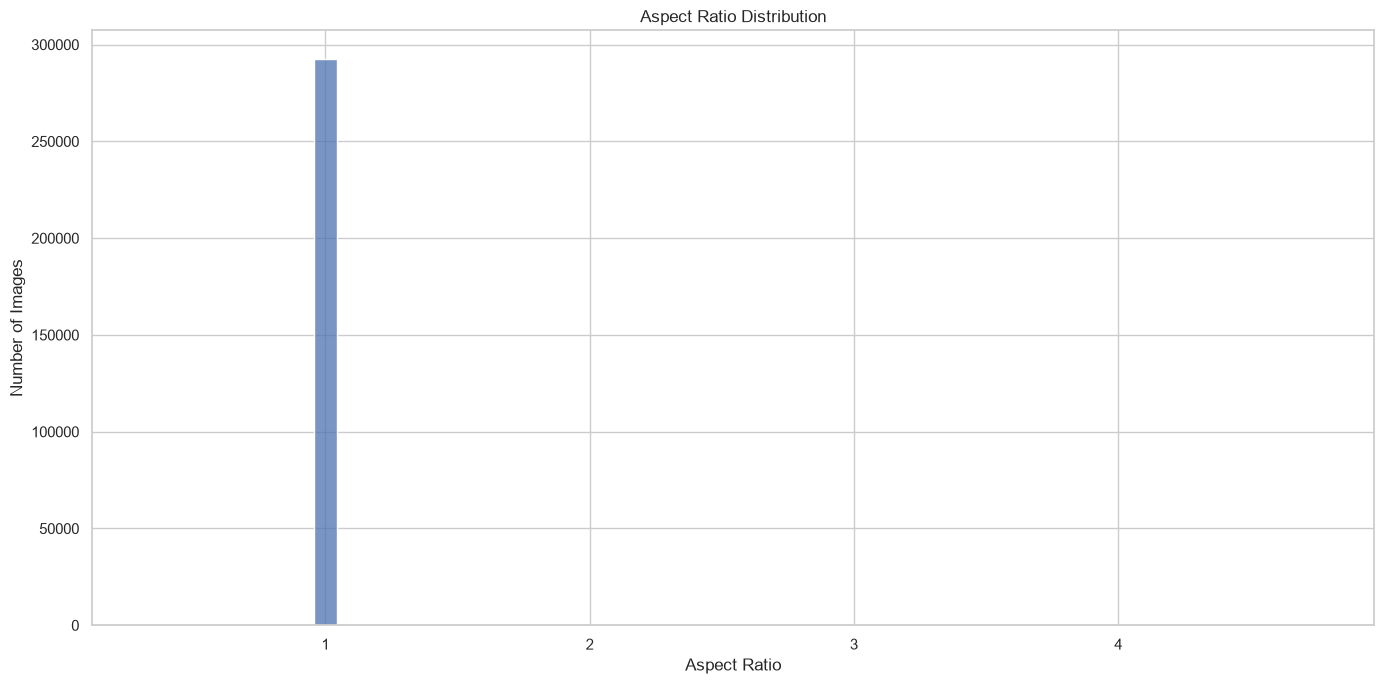

In [30]:
# Aspect Ratio Distribution
aspect_distribution = (
    resolution_df["Aspect_Ratio"]
    .value_counts()
    .reset_index()
)

aspect_distribution.columns = [
    "Aspect_Ratio",
    "Images"
]

print(
    f"Unique Aspect Ratios : "
    f"{len(aspect_distribution):,}"
)

display(
    aspect_distribution.head(20)
)

plt.figure(figsize=(14, 7))

sns.histplot(
    data=resolution_df,
    x="Aspect_Ratio",
    bins=50
)

plt.title(
    "Aspect Ratio Distribution"
)

plt.xlabel(
    "Aspect Ratio"
)

plt.ylabel(
    "Number of Images"
)

plt.tight_layout()
plt.show()


In [31]:
# SQUARE VS NON-SQUARE IMAGES
resolution_df["Shape_Type"] = np.where(
    resolution_df["Width"]
    == resolution_df["Height"],
    "Square",
    "Non-Square"
)

shape_distribution = (
    resolution_df["Shape_Type"]
    .value_counts()
    .reset_index()
)

shape_distribution.columns = [
    "Shape_Type",
    "Images"
]

display(
    shape_distribution
)

non_square_count = (
    resolution_df["Shape_Type"]
    .eq("Non-Square")
    .sum()
)

non_square_percentage = (
    non_square_count
    / len(resolution_df)
    * 100
)

print(
    f"Non-Square Images : "
    f"{non_square_count:,}"
)

print(
    f"Percentage Non-Square : "
    f"{non_square_percentage:.2f}%"
)

,Shape_Type,Images
0,Square,292554
1,Non-Square,2141


Non-Square Images : 2,141
Percentage Non-Square : 0.73%


OVERALL IMAGE MODES


,Mode,Images
0,RGB,294684
1,CMYK,5
2,RGBA,5
3,L,1


Total Image Modes : 4

DATASET-WISE IMAGE MODES


,Dataset,Mode,Images
0,Fruits-360,RGB,182942
1,New Plant Diseases,RGB,87841
2,PlantDoc,CMYK,5
3,PlantDoc,L,1
4,PlantDoc,RGB,2905
5,PlantDoc,RGBA,5
6,Vegetable Dataset,RGB,20996


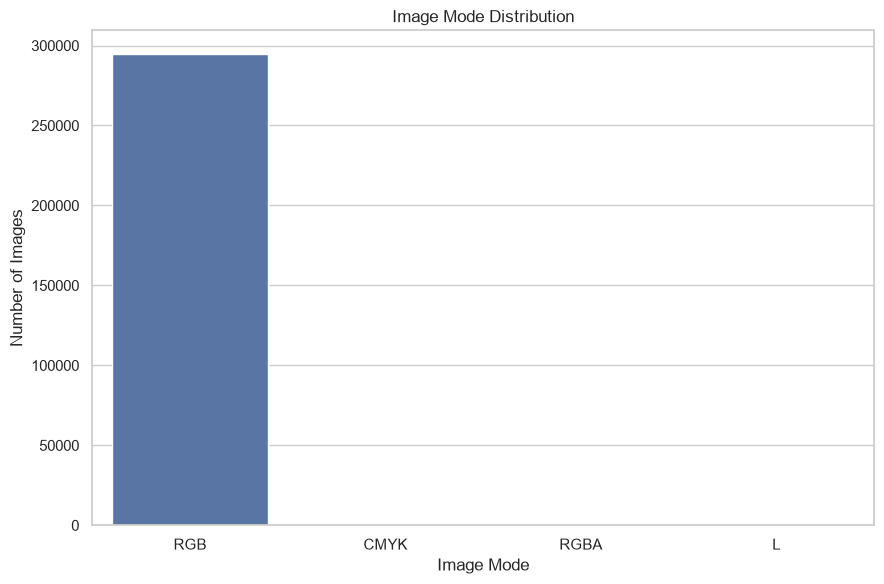

In [32]:
# Image Mode Distribution
mode_distribution = (
    resolution_df["Mode"]
    .value_counts()
    .reset_index()
)

mode_distribution.columns = [
    "Mode",
    "Images"
]

print("OVERALL IMAGE MODES")

display(
    mode_distribution
)

print(
    f"Total Image Modes : "
    f"{len(mode_distribution)}"
)

print()
print("DATASET-WISE IMAGE MODES")

dataset_mode_distribution = (
    resolution_df
    .groupby(
        [
            "Dataset",
            "Mode"
        ]
    )
    .size()
    .reset_index(
        name="Images"
    )
)

display(
    dataset_mode_distribution
)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=mode_distribution,
    x="Mode",
    y="Images"
)

plt.title(
    "Image Mode Distribution"
)

plt.xlabel("Image Mode")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

# Image Quality Visualization

In [33]:
# IMAGE QUALITY STATISTICS
quality_statistics = (
    resolution_df[
        [
            "Width",
            "Height",
            "Aspect_Ratio"
        ]
    ]
    .describe()
)

display(
    quality_statistics
)

print()
print(
    f"Total Images Analyzed : "
    f"{len(resolution_df):,}"
)

,Width,Height,Aspect_Ratio
count,294695.000000,294695.000000,294695.000000
mean,163.364071,162.260296,1.001764
std,130.237873,117.804836,0.035818
min,100.000000,69.000000,0.339000
25%,100.000000,100.000000,1.000000
50%,100.000000,100.000000,1.000000
75%,256.000000,256.000000,1.000000
max,6000.000000,6000.000000,4.747000



Total Images Analyzed : 294,695


In [34]:
#  Small Images
small_images = resolution_df[
    (
        resolution_df["Width"] < 100
    )
    |
    (
        resolution_df["Height"] < 100
    )
].copy()

print(
    "Images Smaller Than 100px "
    "in Any Dimension : "
    f"{len(small_images):,}"
)

if len(small_images) > 0:

    display(
        small_images[
            [
                "Dataset",
                "Class",
                "Filename",
                "Width",
                "Height",
                "Resolution"
            ]
        ].head(20)
    )

Images Smaller Than 100px in Any Dimension : 3


,Dataset,Class,Filename,Width,Height,Resolution
270806,PlantDoc,Apple_Scab_Leaf,test_Apple Scab Leaf_4.jpg,115,85,115 x 85
271000,PlantDoc,Tomato_leaf_mosaic_virus,test_Tomato leaf mosaic virus_8.jpg,130,69,130 x 69
273501,PlantDoc,Tomato_mold_leaf,train_Tomato mold leaf_4.jpg,115,85,115 x 85


In [35]:
# HIGH RESOLUTION IMAGE ANALYSIS
large_images = resolution_df[
    (
        resolution_df["Width"] >= 1000
    )
    |
    (
        resolution_df["Height"] >= 1000
    )
].copy()

print(
    "Images With Dimension >= 1000px : "
    f"{len(large_images):,}"
)

if len(large_images) > 0:

    display(
        large_images[
            [
                "Dataset",
                "Class",
                "Filename",
                "Width",
                "Height",
                "Resolution"
            ]
        ].head(20)
    )

Images With Dimension >= 1000px : 1,023


,Dataset,Class,Filename,Width,Height,Resolution
270783,PlantDoc,Apple_leaf,test_Apple leaf_1.jpg,2988,3054,2988 x 3054
270784,PlantDoc,Apple_leaf,test_Apple leaf_2.jpg,2768,2768,2768 x 2768
270785,PlantDoc,Apple_leaf,test_Apple leaf_3.jpg,2988,2988,2988 x 2988
270788,PlantDoc,Apple_leaf,test_Apple leaf_6.jpg,1300,1174,1300 x 1174
270789,PlantDoc,Apple_leaf,test_Apple leaf_7.jpg,1300,957,1300 x 957
270790,PlantDoc,Apple_leaf,test_Apple leaf_8.jpg,2160,2160,2160 x 2160
270792,PlantDoc,Apple_rust_leaf,test_Apple rust leaf_1.jpg,3406,2988,3406 x 2988
270793,PlantDoc,Apple_rust_leaf,test_Apple rust leaf_10.jpg,2448,2576,2448 x 2576
270799,PlantDoc,Apple_rust_leaf,test_Apple rust leaf_7.jpg,3264,2448,3264 x 2448
270817,PlantDoc,Bell_pepper_leaf,test_Bell_pepper leaf_6.jpg,2147,1432,2147 x 1432


In [36]:
# Dataset-wise Quality Comparison
dataset_quality = (
    resolution_df
    .groupby("Dataset")
    .agg(

        Total_Images=(
            "Width",
            "count"
        ),

        Average_Width=(
            "Width",
            "mean"
        ),

        Average_Height=(
            "Height",
            "mean"
        ),

        Minimum_Width=(
            "Width",
            "min"
        ),

        Maximum_Width=(
            "Width",
            "max"
        ),

        Minimum_Height=(
            "Height",
            "min"
        ),

        Maximum_Height=(
            "Height",
            "max"
        ),

        Non_Square_Images=(
            "Shape_Type",
            lambda x:
            (x == "Non-Square").sum()
        )

    )
    .reset_index()
)

dataset_quality[
    [
        "Average_Width",
        "Average_Height"
    ]
] = (
    dataset_quality[
        [
            "Average_Width",
            "Average_Height"
        ]
    ]
    .round(2)
)

display(
    dataset_quality
)

,Dataset,Total_Images,Average_Width,Average_Height,Minimum_Width,Maximum_Width,Minimum_Height,Maximum_Height,Non_Square_Images
0,Fruits-360,182942,100.00,100.00,100,100,100,100,0
1,New Plant Diseases,87841,256.00,256.00,256,256,256,256,0
2,PlantDoc,2916,911.51,800.03,115,6000,69,6000,2132
3,Vegetable Dataset,20996,224.00,223.99,224,224,187,224,9


# Sample Image Visualization

In [37]:
# RANDOM IMAGE SAMPLE
import random

sample_size = 12

sample_df = (
    image_metadata_df
    .sample(
        n=min(
            sample_size,
            len(image_metadata_df)
        ),
        random_state=42
    )
    .copy()
)

display(
    sample_df[
        [
            "Dataset",
            "Class",
            "Filename",
            "Label"
        ]
    ]
)

,Dataset,Class,Filename,Label
173811,Fruits-360,fruits-360_100x100,r_134_100.jpg,79
24030,Fruits-360,fruits-360_100x100,r0_131_100.jpg,79
90786,Fruits-360,fruits-360_100x100,r0_124_100.jpg,79
190760,New Plant Diseases,Blueberry___healthy,04c891f2-2039-4a50-b99b-a8b103276a37___RS_HL 2...,11
105776,Fruits-360,fruits-360_100x100,234_100.jpg,79
136112,Fruits-360,fruits-360_100x100,r0_82_100.jpg,79
171070,Fruits-360,fruits-360_100x100,r2_212_100.jpg,79
91245,Fruits-360,fruits-360_100x100,r1_206_100.jpg,79
4095,Fruits-360,fruits-360_100x100,38_100.jpg,79
47037,Fruits-360,fruits-360_100x100,r1_42_100.jpg,79


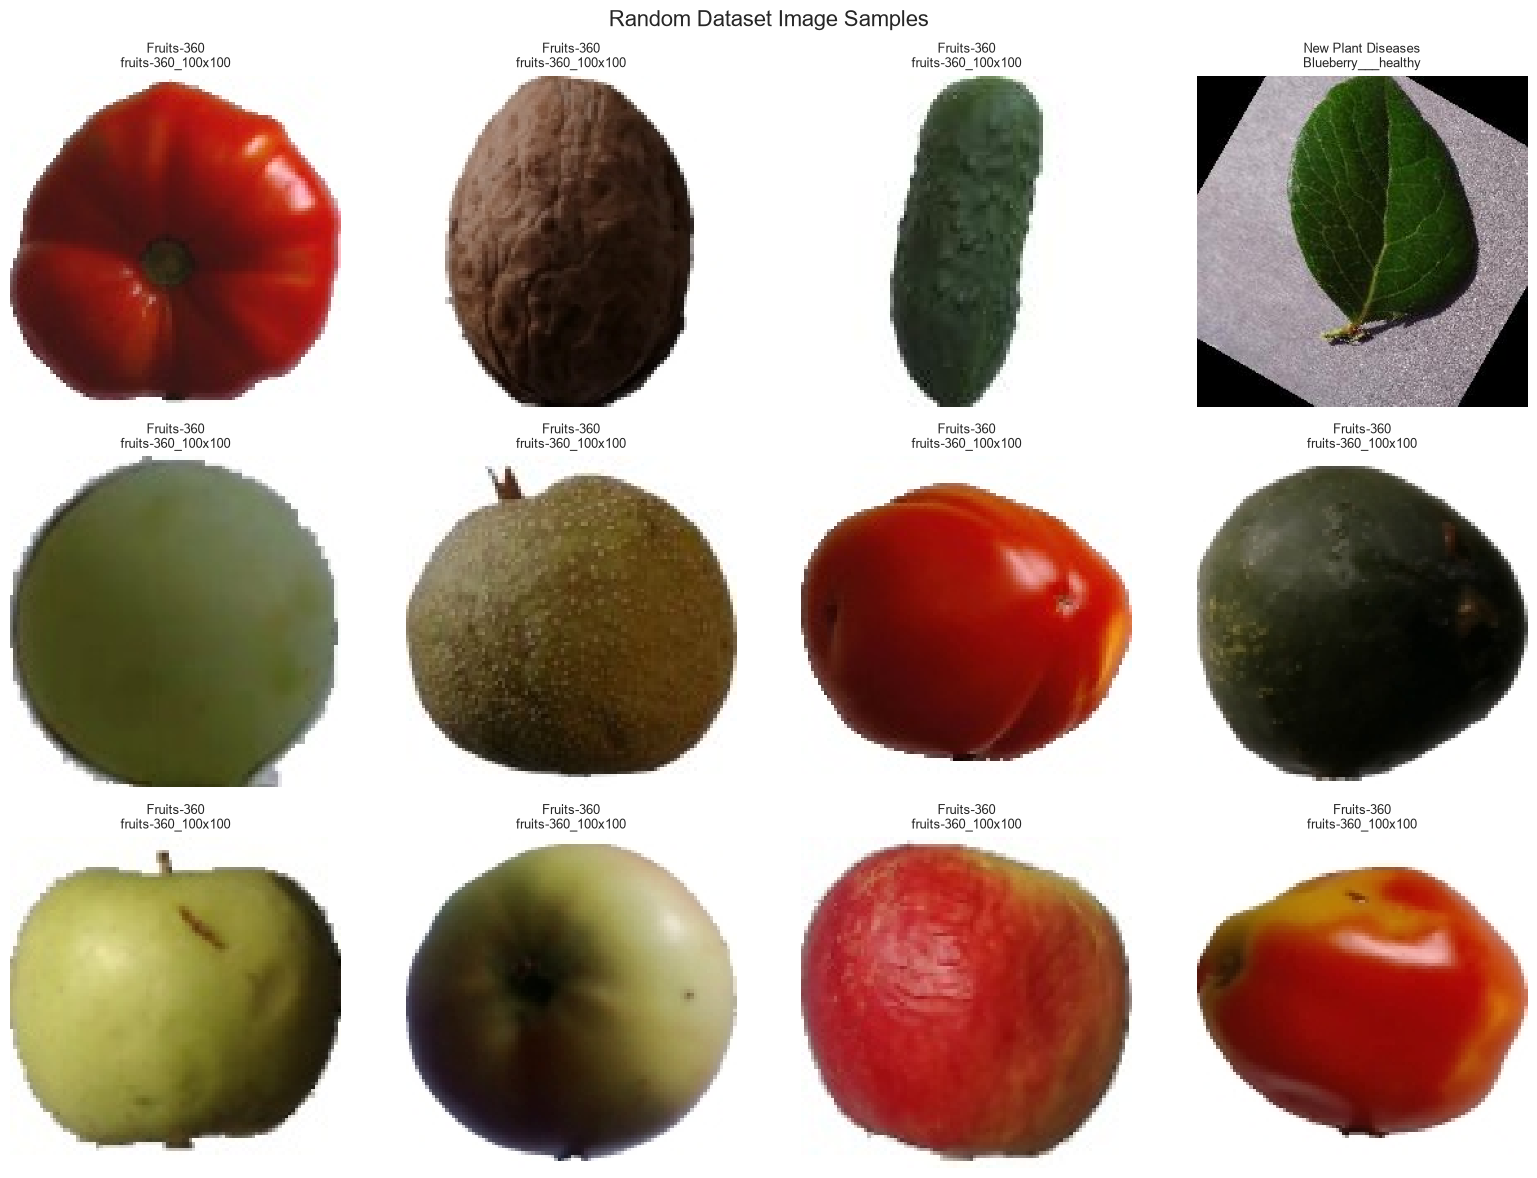

In [38]:
# DISPLAY RANDOM IMAGE SAMPLES
fig, axes = plt.subplots(
    3,
    4,
    figsize=(16, 12)
)

axes = axes.flatten()

for ax, (_, row) in zip(
    axes,
    sample_df.iterrows()
):

    actual_path = resolve_image_path(
        row["Image_Path"]
    )

    if actual_path is not None:

        try:

            with Image.open(actual_path) as img:

                ax.imshow(img)

                ax.set_title(
                    f"{row['Dataset']}\n"
                    f"{row['Class']}",
                    fontsize=9
                )

        except Exception:

            ax.text(
                0.5,
                0.5,
                "Image Error",
                ha="center",
                va="center"
            )

    else:

        ax.text(
            0.5,
            0.5,
            "Path Not Found",
            ha="center",
            va="center"
        )

    ax.axis("off")


plt.suptitle(
    "Random Dataset Image Samples",
    fontsize=16
)

plt.tight_layout()
plt.show()

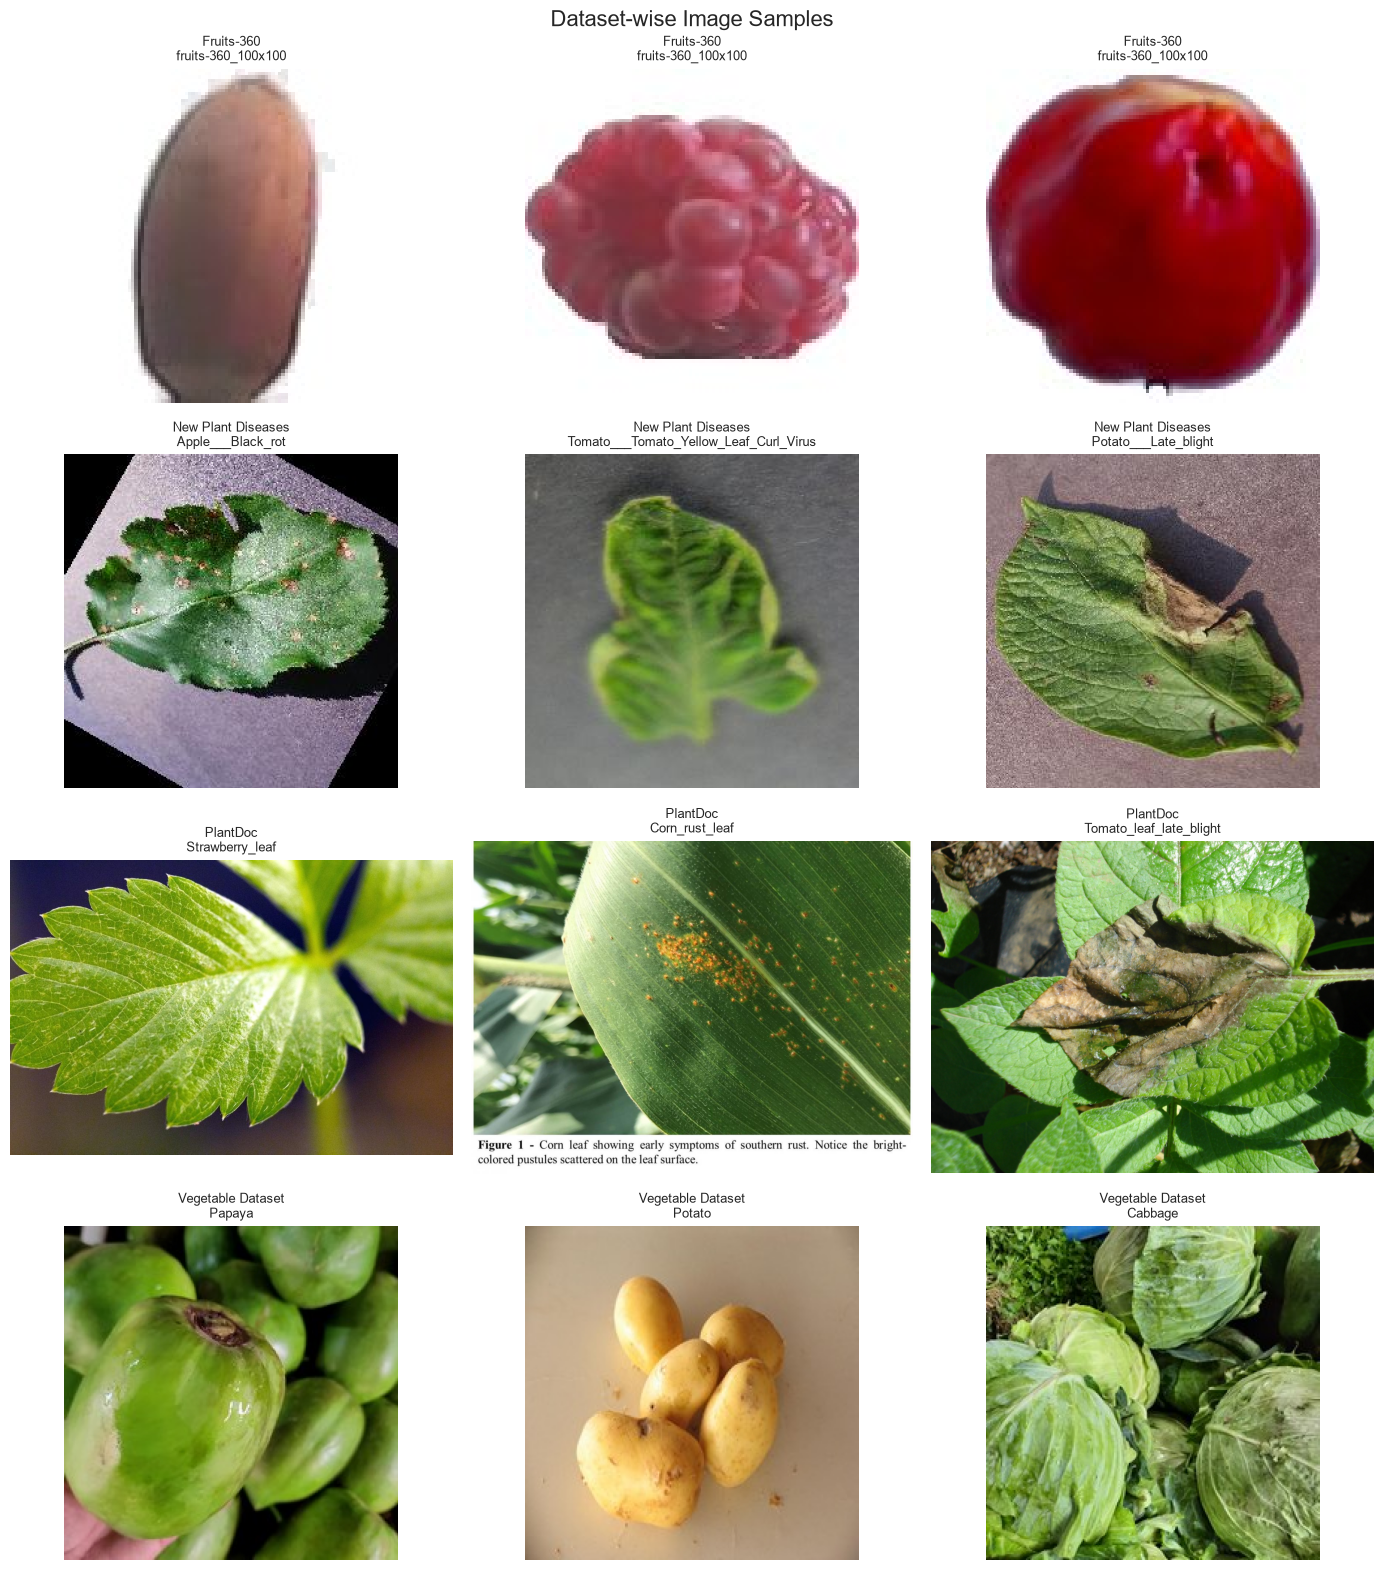

In [39]:
# Dataset-wise Samples
datasets_available = (
    image_metadata_df["Dataset"]
    .dropna()
    .unique()
)

sample_per_dataset = 3

fig, axes = plt.subplots(
    len(datasets_available),
    sample_per_dataset,
    figsize=(14, 4 * len(datasets_available))
)

if len(datasets_available) == 1:

    axes = np.array([axes])

for row_index, dataset_name in enumerate(
    datasets_available
):

    dataset_samples = (
        image_metadata_df[
            image_metadata_df["Dataset"]
            == dataset_name
        ]
        .sample(
            n=min(
                sample_per_dataset,
                (
                    image_metadata_df["Dataset"]
                    == dataset_name
                ).sum()
            ),
            random_state=42
        )
    )

    for col_index in range(
        sample_per_dataset
    ):

        ax = axes[
            row_index,
            col_index
        ]

        ax.axis("off")

        if col_index >= len(
            dataset_samples
        ):
            continue

        sample_row = dataset_samples.iloc[
            col_index
        ]

        actual_path = resolve_image_path(
            sample_row["Image_Path"]
        )

        if actual_path is not None:

            try:

                with Image.open(
                    actual_path
                ) as img:

                    ax.imshow(img)

                    ax.set_title(
                        f"{dataset_name}\n"
                        f"{sample_row['Class']}",
                        fontsize=9
                    )

            except Exception:

                ax.set_title(
                    "Image Error"
                )

        else:

            ax.set_title(
                "Path Not Found"
            )


plt.suptitle(
    "Dataset-wise Image Samples",
    fontsize=16
)

plt.tight_layout()
plt.show()

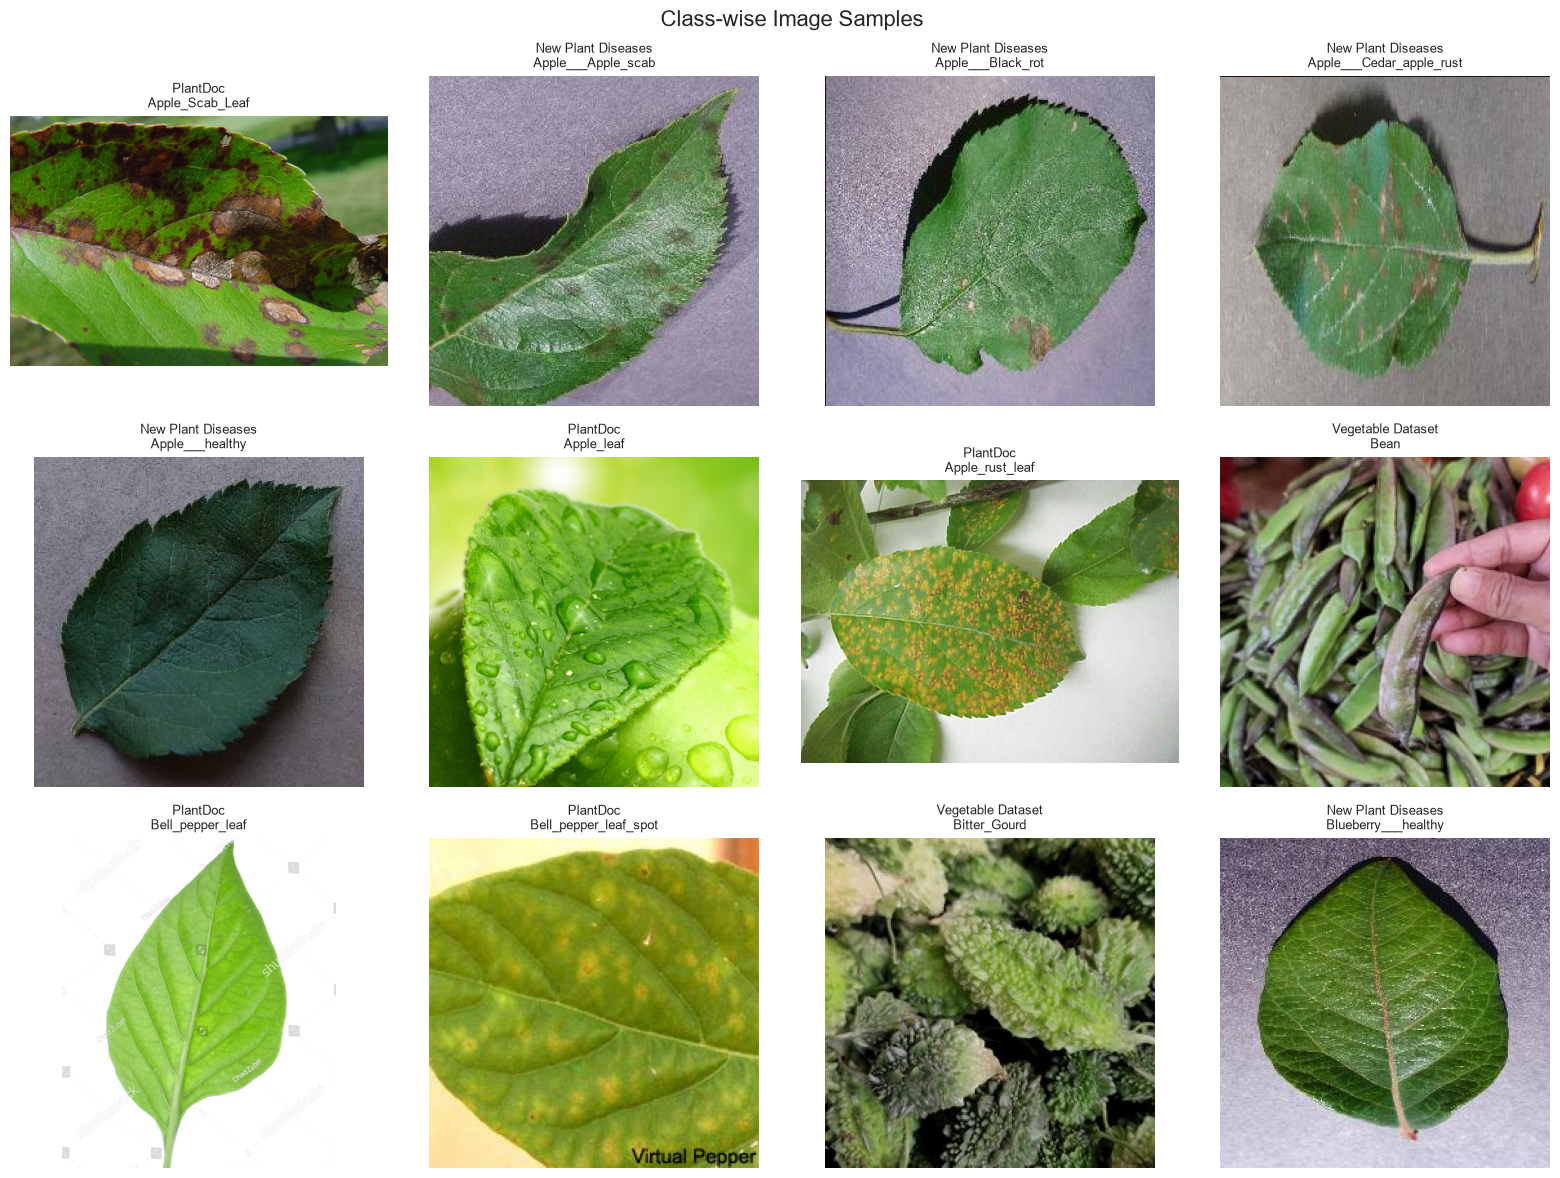

In [40]:
# CLASS-WISE IMAGE SAMPLES
class_sample_df = (
    image_metadata_df
    .groupby("Class", group_keys=False)
    .sample(
        n=1,
        random_state=42
    )
)

class_sample_df = (
    class_sample_df
    .head(12)
)

fig, axes = plt.subplots(
    3,
    4,
    figsize=(16, 12)
)

axes = axes.flatten()

for ax, (_, row) in zip(
    axes,
    class_sample_df.iterrows()
):

    actual_path = resolve_image_path(
        row["Image_Path"]
    )

    if actual_path is not None:

        try:

            with Image.open(
                actual_path
            ) as img:

                ax.imshow(img)

                ax.set_title(
                    f"{row['Dataset']}\n"
                    f"{row['Class']}",
                    fontsize=9
                )

        except Exception:

            ax.text(
                0.5,
                0.5,
                "Image Error",
                ha="center",
                va="center"
            )

    else:

        ax.text(
            0.5,
            0.5,
            "Path Not Found",
            ha="center",
            va="center"
        )

    ax.axis("off")


plt.suptitle(
    "Class-wise Image Samples",
    fontsize=16
)

plt.tight_layout()
plt.show()


# Statistical Charts & Comparative Analysis

DATASET IMAGE DISTRIBUTION


,Dataset,Images
0,Fruits-360,182942
1,New Plant Diseases,87841
3,Vegetable Dataset,20996
2,PlantDoc,2916


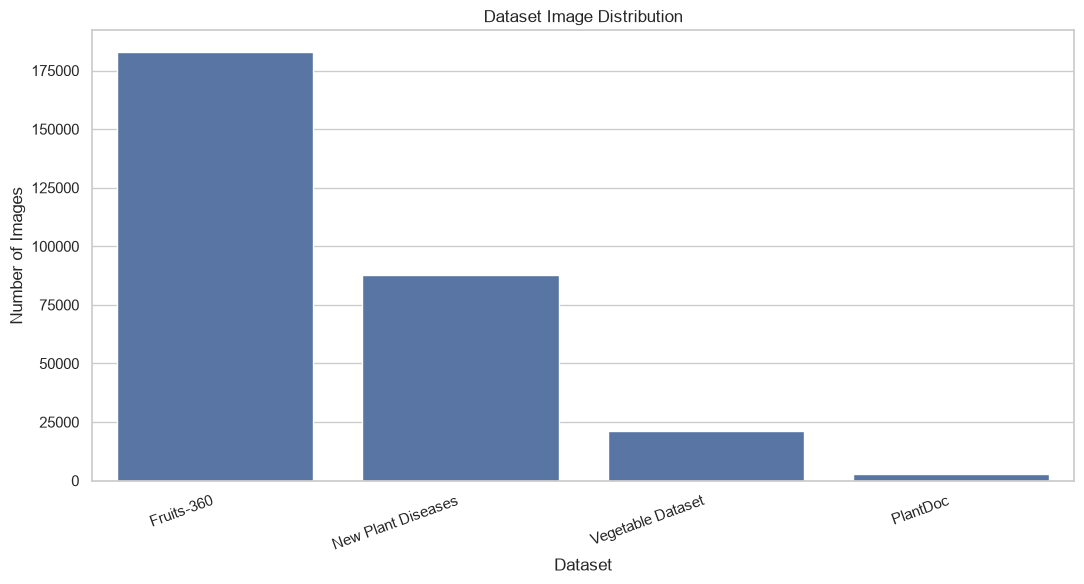

In [41]:
# DATASET IMAGE DISTRIBUTION

print("DATASET IMAGE DISTRIBUTION")


dataset_image_distribution = (
    image_metadata_df
    .groupby("Dataset")
    .size()
    .reset_index(name="Images")
    .sort_values("Images", ascending=False)
)

display(dataset_image_distribution)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=dataset_image_distribution,
    x="Dataset",
    y="Images"
)

plt.title("Dataset Image Distribution")
plt.xlabel("Dataset")
plt.ylabel("Number of Images")

plt.xticks(rotation=20, ha="right")

plt.tight_layout()
plt.show()

CLASS DISTRIBUTION


,Dataset,Classes
1,New Plant Diseases,38
2,PlantDoc,28
3,Vegetable Dataset,15
0,Fruits-360,1


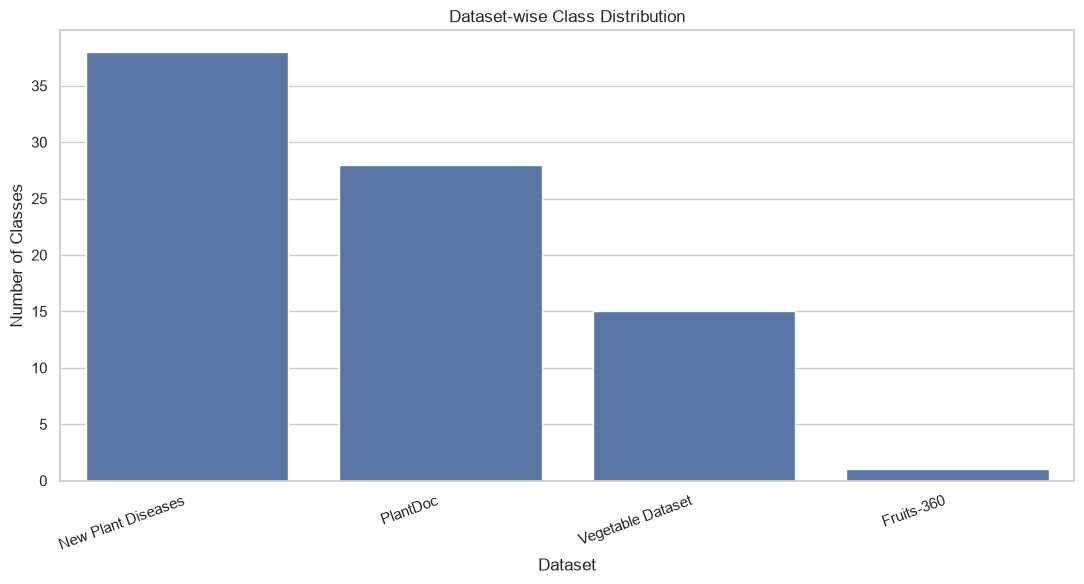

In [42]:
# CLASS DISTRIBUTION

print("CLASS DISTRIBUTION")

class_distribution = (
    image_metadata_df
    .groupby("Dataset")["Class"]
    .nunique()
    .reset_index(name="Classes")
    .sort_values("Classes", ascending=False)
)

display(class_distribution)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=class_distribution,
    x="Dataset",
    y="Classes"
)

plt.title("Dataset-wise Class Distribution")
plt.xlabel("Dataset")
plt.ylabel("Number of Classes")

plt.xticks(rotation=20, ha="right")

plt.tight_layout()
plt.show()

TRAIN / VALIDATION / TEST DISTRIBUTION


,Dataset,Split,Images
0,Fruits-360,Unsplit,182942
1,New Plant Diseases,Train,70277
2,New Plant Diseases,Validation,17564
3,PlantDoc,Test,252
4,PlantDoc,Train,2664
5,Vegetable Dataset,Test,3000
6,Vegetable Dataset,Train,14996
7,Vegetable Dataset,Validation,3000


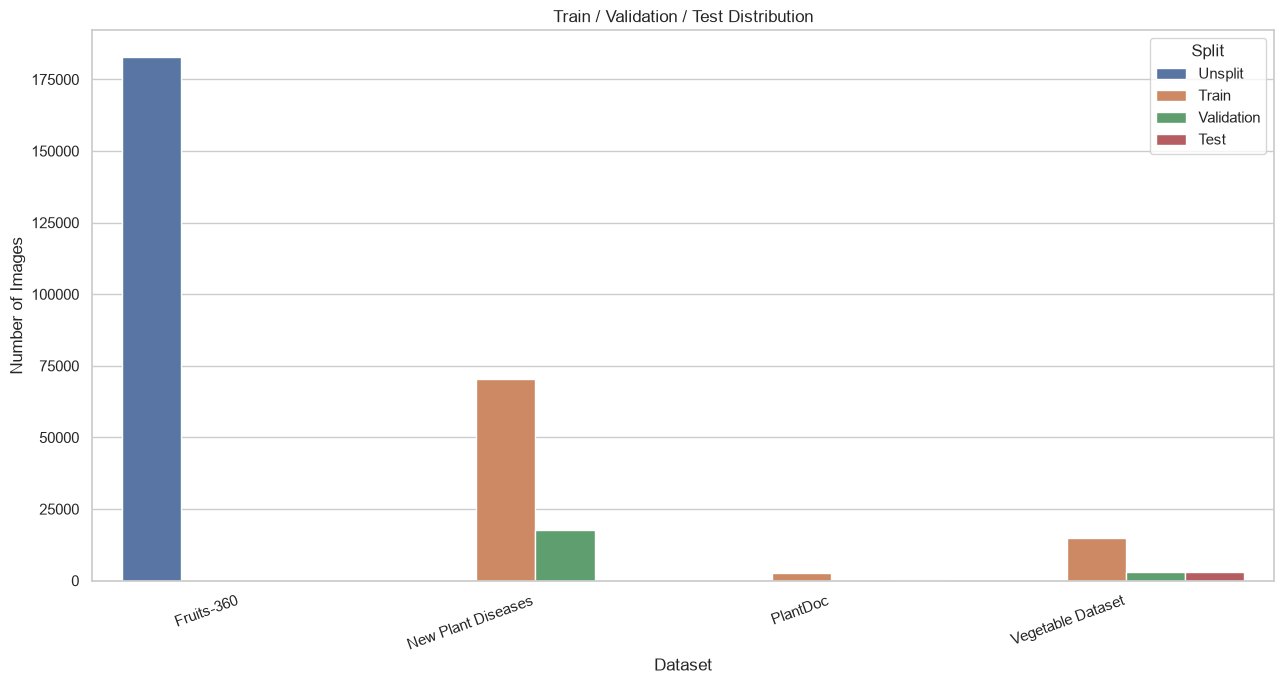

In [43]:
# Train / Validation / Test Distribution

print("TRAIN / VALIDATION / TEST DISTRIBUTION")


split_distribution = (
    image_metadata_df
    .groupby(["Dataset", "Split"])
    .size()
    .reset_index(name="Images")
)

display(split_distribution)

plt.figure(figsize=(13, 7))

sns.barplot(
    data=split_distribution,
    x="Dataset",
    y="Images",
    hue="Split"
)

plt.title(
    "Train / Validation / Test Distribution"
)

plt.xlabel("Dataset")
plt.ylabel("Number of Images")

plt.xticks(rotation=20, ha="right")

plt.tight_layout()
plt.show()

 RESOLUTION DISTRIBUTION


,Resolution,Images
0,100 x 100,182942
581,256 x 256,87841
527,224 x 224,20987
673,300 x 300,213
410,1600 x 1200,56
1633,800 x 600,42
68,1024 x 768,34
179,1200 x 1600,23
1438,640 x 480,20
1717,900 x 675,19


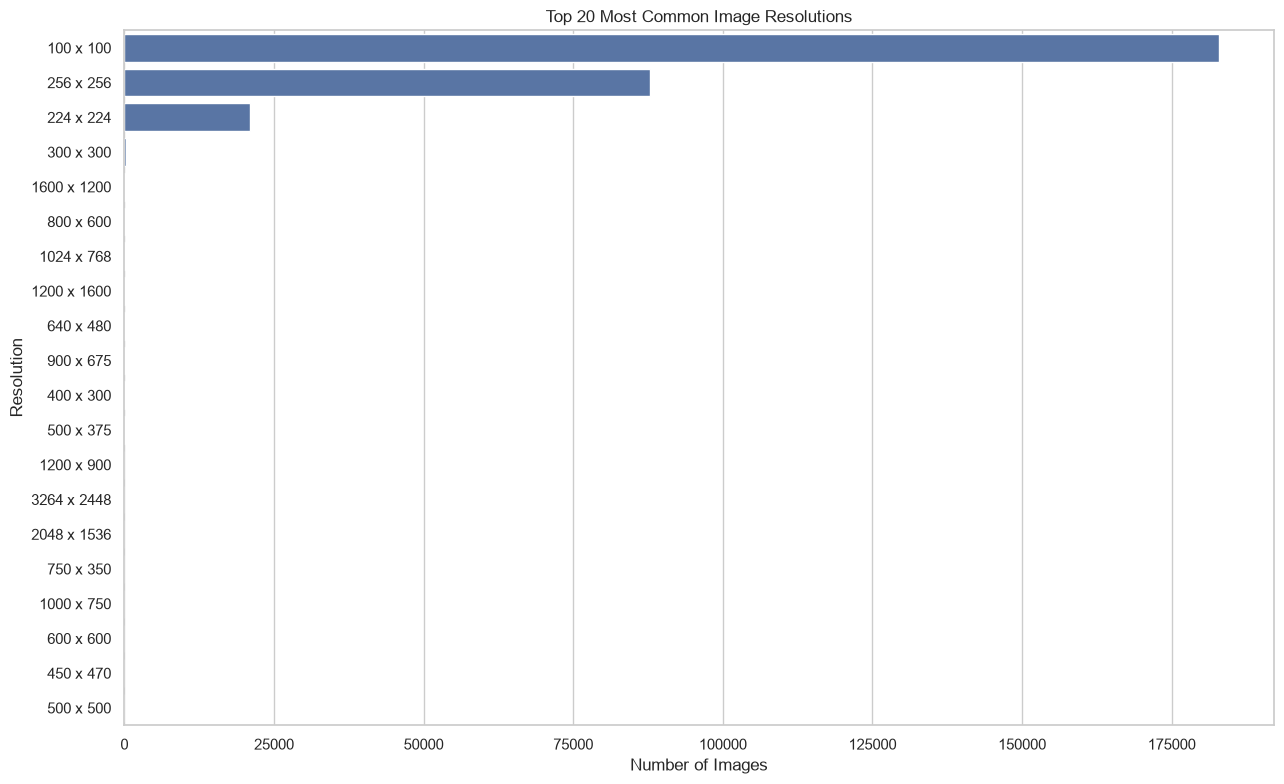

In [44]:
# RESOLUTION DISTRIBUTION

print(" RESOLUTION DISTRIBUTION")


resolution_distribution_chart = (
    resolution_df
    .groupby("Resolution")
    .size()
    .reset_index(name="Images")
    .sort_values("Images", ascending=False)
    .head(20)
)

display(resolution_distribution_chart)

plt.figure(figsize=(13, 8))

sns.barplot(
    data=resolution_distribution_chart,
    y="Resolution",
    x="Images"
)

plt.title(
    "Top 20 Most Common Image Resolutions"
)

plt.xlabel("Number of Images")
plt.ylabel("Resolution")

plt.tight_layout()
plt.show()

ASPECT RATIO DISTRIBUTION


,Aspect_Ratio,Images
0,1.000,292555
1,1.333,424
2,0.750,121
3,1.500,82
4,1.332,28
5,0.562,24
6,1.334,22
7,0.667,20
8,1.501,20
9,1.502,16


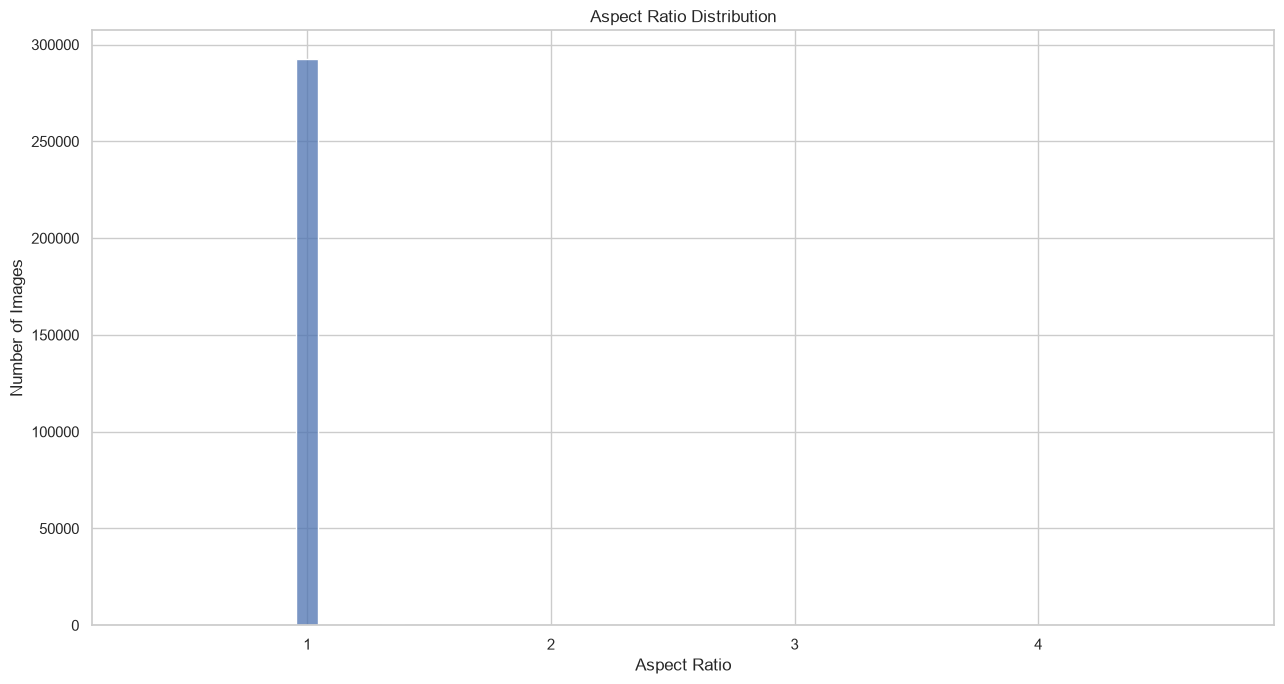

In [45]:
# ASPECT RATIO DISTRIBUTION

print("ASPECT RATIO DISTRIBUTION")


aspect_ratio_distribution = (
    resolution_df["Aspect_Ratio"]
    .value_counts()
    .reset_index()
)

aspect_ratio_distribution.columns = [
    "Aspect_Ratio",
    "Images"
]

display(
    aspect_ratio_distribution.head(20)
)

plt.figure(figsize=(13, 7))

sns.histplot(
    data=resolution_df,
    x="Aspect_Ratio",
    bins=50
)

plt.title("Aspect Ratio Distribution")
plt.xlabel("Aspect Ratio")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

IMAGE MODE DISTRIBUTION


,Mode,Images
0,RGB,294684
1,CMYK,5
2,RGBA,5
3,L,1


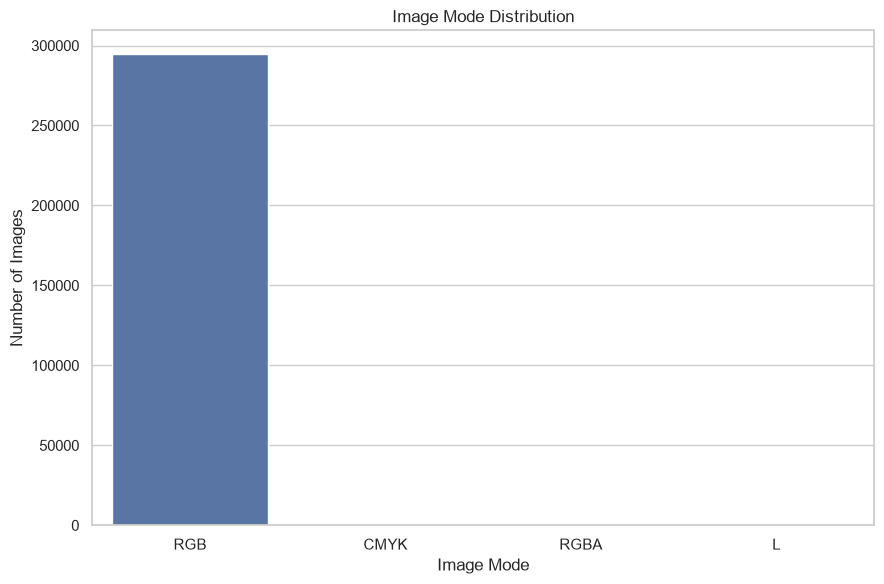

In [46]:
# IMAGE MODE DISTRIBUTION

print("IMAGE MODE DISTRIBUTION")


mode_distribution_chart = (
    resolution_df["Mode"]
    .value_counts()
    .reset_index()
)

mode_distribution_chart.columns = [
    "Mode",
    "Images"
]

display(
    mode_distribution_chart
)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=mode_distribution_chart,
    x="Mode",
    y="Images"
)

plt.title("Image Mode Distribution")
plt.xlabel("Image Mode")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

DATASET-WISE RESOLUTION COMPARISON


,Dataset,Average_Width,Average_Height
0,Fruits-360,100.00,100.00
1,New Plant Diseases,256.00,256.00
2,PlantDoc,911.51,800.03
3,Vegetable Dataset,224.00,223.99


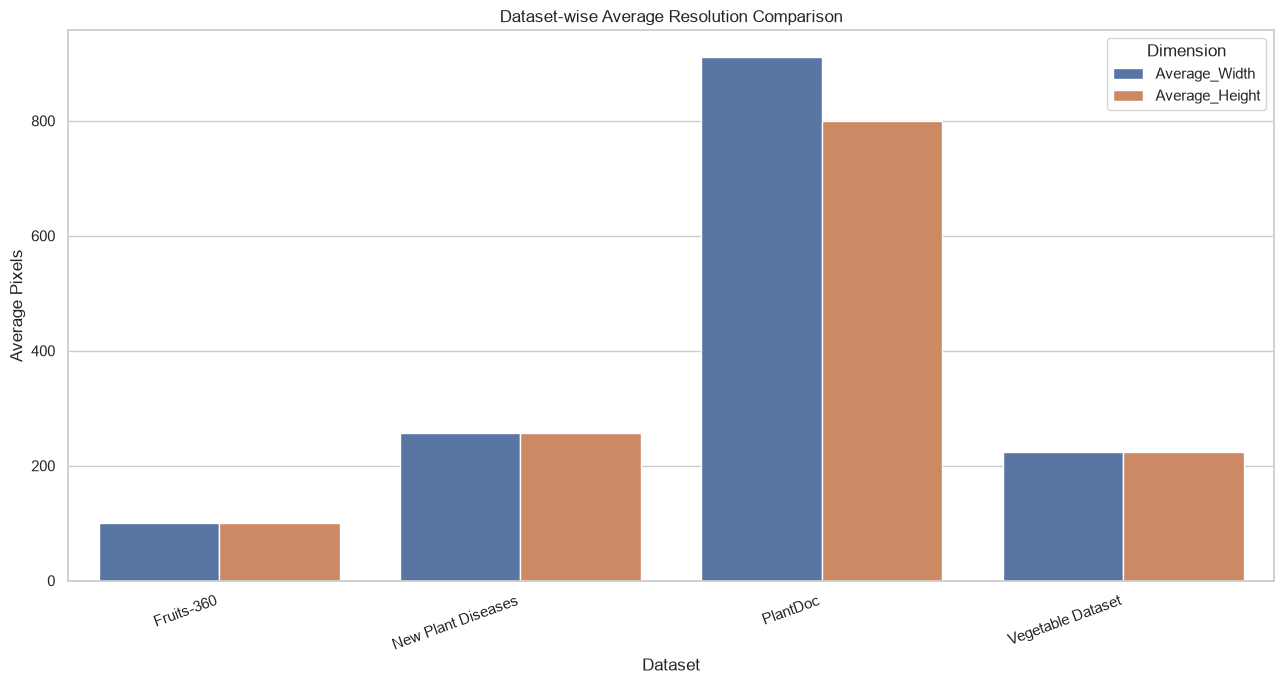

In [47]:
# Dataset-wise Resolution Comparison

print("DATASET-WISE RESOLUTION COMPARISON")


resolution_comparison = (
    resolution_df
    .groupby("Dataset")
    .agg(
        Average_Width=("Width", "mean"),
        Average_Height=("Height", "mean")
    )
    .reset_index()
)

resolution_comparison[
    ["Average_Width", "Average_Height"]
] = resolution_comparison[
    ["Average_Width", "Average_Height"]
].round(2)

display(resolution_comparison)

resolution_comparison_long = (
    resolution_comparison
    .melt(
        id_vars="Dataset",
        value_vars=[
            "Average_Width",
            "Average_Height"
        ],
        var_name="Dimension",
        value_name="Pixels"
    )
)

plt.figure(figsize=(13, 7))

sns.barplot(
    data=resolution_comparison_long,
    x="Dataset",
    y="Pixels",
    hue="Dimension"
)

plt.title(
    "Dataset-wise Average Resolution Comparison"
)

plt.xlabel("Dataset")
plt.ylabel("Average Pixels")

plt.xticks(rotation=20, ha="right")

plt.tight_layout()
plt.show()

DATASET-WISE NON-SQUARE IMAGES


,Dataset,Total_Images,Non_Square_Images,Percentage_Non_Square
0,Fruits-360,182942,0,0.00
1,New Plant Diseases,87841,0,0.00
2,PlantDoc,2916,2132,73.11
3,Vegetable Dataset,20996,9,0.04


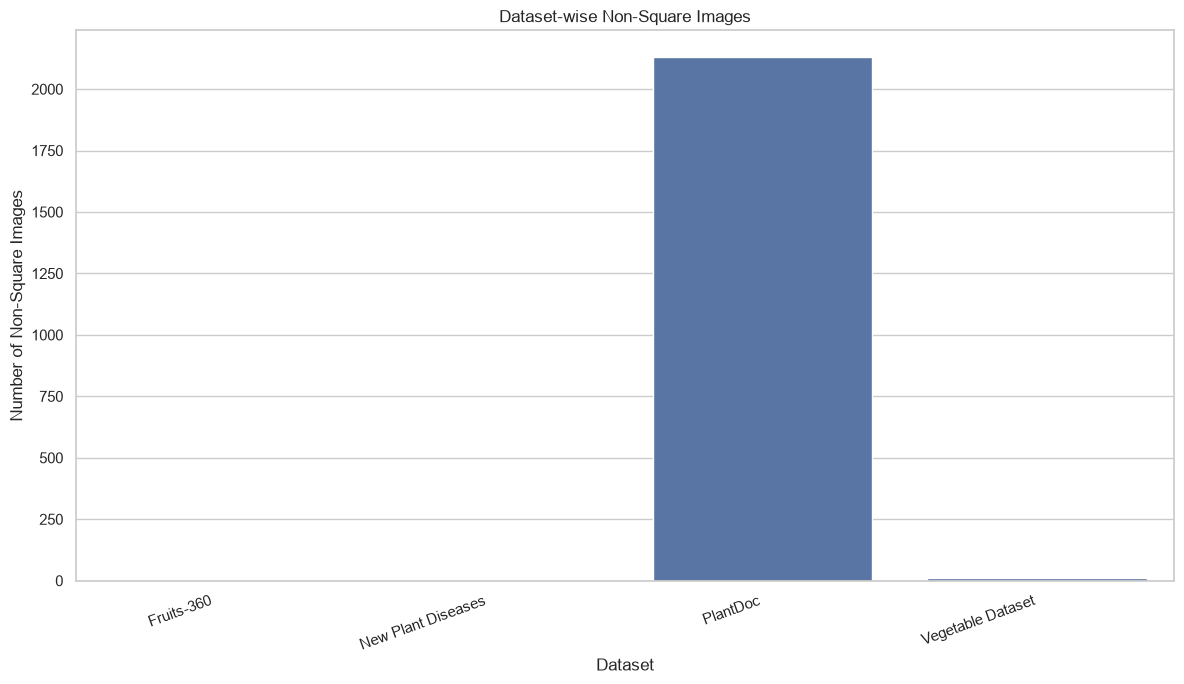

In [48]:
# Dataset-wise Non-Square Images

print("DATASET-WISE NON-SQUARE IMAGES")


non_square_comparison = (
    resolution_df
    .groupby("Dataset")
    .agg(
        Total_Images=("Width", "count"),
        Non_Square_Images=(
            "Shape_Type",
            lambda x: (x == "Non-Square").sum()
        )
    )
    .reset_index()
)

non_square_comparison["Percentage_Non_Square"] = (
    non_square_comparison["Non_Square_Images"]
    / non_square_comparison["Total_Images"]
    * 100
).round(2)

display(non_square_comparison)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=non_square_comparison,
    x="Dataset",
    y="Non_Square_Images"
)

plt.title(
    "Dataset-wise Non-Square Images"
)

plt.xlabel("Dataset")
plt.ylabel("Number of Non-Square Images")

plt.xticks(rotation=20, ha="right")

plt.tight_layout()
plt.show()

DATASET-WISE IMAGE QUALITY COMPARISON


,Dataset,Average_Width,Average_Height,Average_Aspect_Ratio,Non_Square_Images
0,Fruits-360,100.00,100.00,1.00,0
1,New Plant Diseases,256.00,256.00,1.00,0
2,PlantDoc,911.51,800.03,1.18,2132
3,Vegetable Dataset,224.00,223.99,1.00,9


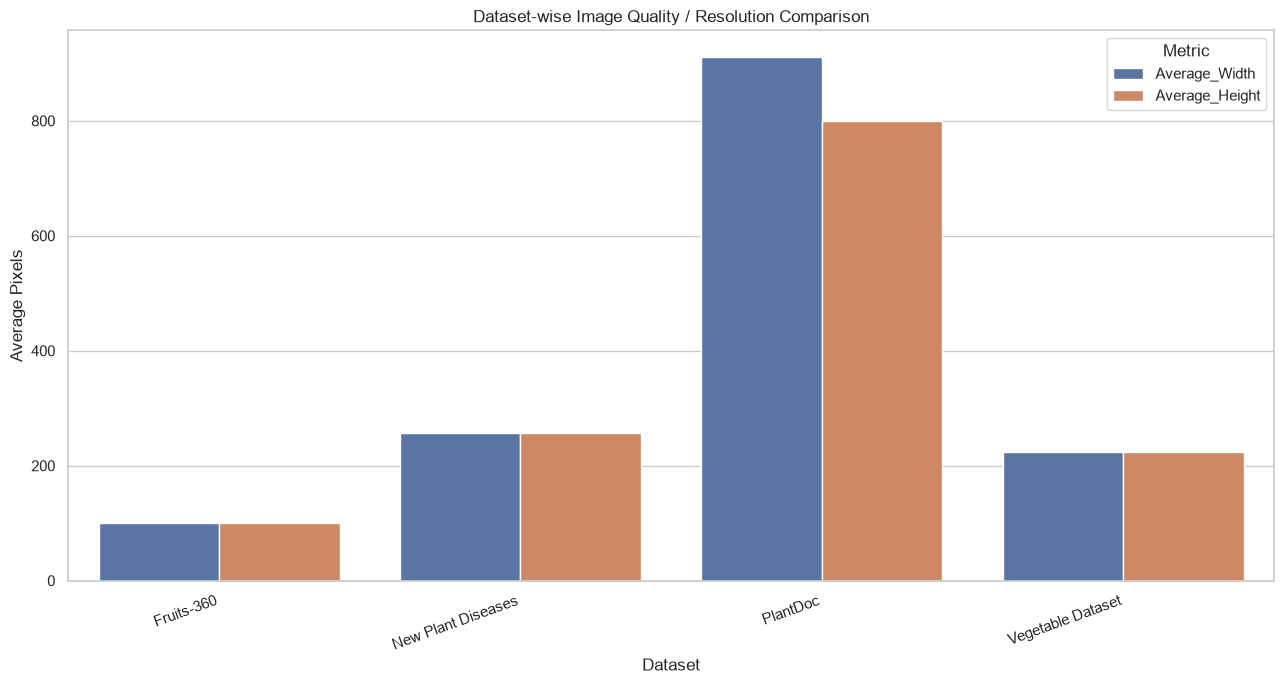

In [49]:
# DATASET-WISE IMAGE QUALITY COMPARISON

print("DATASET-WISE IMAGE QUALITY COMPARISON")


quality_comparison = (
    resolution_df
    .groupby("Dataset")
    .agg(
        Average_Width=("Width", "mean"),
        Average_Height=("Height", "mean"),
        Average_Aspect_Ratio=(
            "Aspect_Ratio",
            "mean"
        ),
        Non_Square_Images=(
            "Shape_Type",
            lambda x: (x == "Non-Square").sum()
        )
    )
    .reset_index()
)

quality_comparison[
    [
        "Average_Width",
        "Average_Height",
        "Average_Aspect_Ratio"
    ]
] = quality_comparison[
    [
        "Average_Width",
        "Average_Height",
        "Average_Aspect_Ratio"
    ]
].round(2)

display(quality_comparison)

quality_long = quality_comparison.melt(
    id_vars="Dataset",
    value_vars=[
        "Average_Width",
        "Average_Height"
    ],
    var_name="Metric",
    value_name="Pixels"
)

plt.figure(figsize=(13, 7))

sns.barplot(
    data=quality_long,
    x="Dataset",
    y="Pixels",
    hue="Metric"
)

plt.title(
    "Dataset-wise Image Quality / Resolution Comparison"
)

plt.xlabel("Dataset")
plt.ylabel("Average Pixels")

plt.xticks(rotation=20, ha="right")

plt.tight_layout()
plt.show()

# Final Visualization Report

In [51]:
# STATISTICS


total_images = len(image_metadata_df)

total_datasets = (
    image_metadata_df["Dataset"]
    .nunique()
)

total_classes = (
    image_metadata_df["Class"]
    .nunique()
)

unique_resolutions = (
    resolution_df["Resolution"]
    .nunique()
)

unique_aspect_ratios = (
    resolution_df["Aspect_Ratio"]
    .nunique()
)

image_modes = (
    resolution_df["Mode"]
    .nunique()
)

most_common_resolution = (
    resolution_df["Resolution"]
    .value_counts()
    .idxmax()
)

most_common_resolution_count = (
    resolution_df["Resolution"]
    .value_counts()
    .max()
)

In [52]:
print(f"Total Images          : {total_images:,}")
print(f"Total Datasets        : {total_datasets}")
print(f"Total Classes         : {total_classes}")
print(f"Unique Resolutions    : {unique_resolutions:,}")
print(f"Unique Aspect Ratios  : {unique_aspect_ratios:,}")
print(f"Image Modes           : {image_modes}")
print(f"Most Common Resolution: {most_common_resolution}")
print(
    f"Images at Most Common Resolution : "
    f"{most_common_resolution_count:,}"
)

Total Images          : 294,695
Total Datasets        : 4
Total Classes         : 82
Unique Resolutions    : 1,775
Unique Aspect Ratios  : 698
Image Modes           : 4
Most Common Resolution: 100 x 100
Images at Most Common Resolution : 182,942


In [55]:

# RESOLUTION SUMMARY



print("RESOLUTION SUMMARY")


min_width = resolution_df["Width"].min()
max_width = resolution_df["Width"].max()

min_height = resolution_df["Height"].min()
max_height = resolution_df["Height"].max()

avg_width = resolution_df["Width"].mean()
avg_height = resolution_df["Height"].mean()

non_square_count = (
    resolution_df["Shape_Type"]
    .eq("Non-Square")
    .sum()
)

non_square_percentage = (
    non_square_count / len(resolution_df) * 100
)

print(f"Minimum Width  : {min_width:,.0f} px")
print(f"Maximum Width  : {max_width:,.0f} px")
print(f"Minimum Height : {min_height:,.0f} px")
print(f"Maximum Height : {max_height:,.0f} px")

print()

print(f"Average Width  : {avg_width:,.2f} px")
print(f"Average Height : {avg_height:,.2f} px")

print()

print(f"Non-Square Images     : {non_square_count:,}")
print(f"Non-Square Percentage : {non_square_percentage:.2f}%")



RESOLUTION SUMMARY
Minimum Width  : 100 px
Maximum Width  : 6,000 px
Minimum Height : 69 px
Maximum Height : 6,000 px

Average Width  : 163.36 px
Average Height : 162.26 px

Non-Square Images     : 2,141
Non-Square Percentage : 0.73%


In [56]:
# ASPECT RATIO & IMAGE MODE SUMMARY

print("ASPECT RATIO SUMMARY")


print(
    f"Average Aspect Ratio : "
    f"{resolution_df['Aspect_Ratio'].mean():.3f}"
)

print(
    f"Minimum Aspect Ratio : "
    f"{resolution_df['Aspect_Ratio'].min():.3f}"
)

print(
    f"Maximum Aspect Ratio : "
    f"{resolution_df['Aspect_Ratio'].max():.3f}"
)

print()


print("IMAGE MODE SUMMARY")


mode_summary = (
    resolution_df["Mode"]
    .value_counts()
    .reset_index()
)

mode_summary.columns = [
    "Mode",
    "Images"
]

display(mode_summary)

ASPECT RATIO SUMMARY
Average Aspect Ratio : 1.002
Minimum Aspect Ratio : 0.339
Maximum Aspect Ratio : 4.747

IMAGE MODE SUMMARY


,Mode,Images
0,RGB,294684
1,CMYK,5
2,RGBA,5
3,L,1


In [58]:
# IMPORTANT OBSERVATIONS & FINAL VISUALIZATION REPORT
print("FINAL VISUALIZATION REPORT")


print()
print("IMPORTANT OBSERVATIONS")



# 1. Dataset with highest image count


top_dataset = dataset_image_distribution.iloc[0]["Dataset"]

top_dataset_images = int(
    dataset_image_distribution.iloc[0]["Images"]
)

print(
    f"1. Dataset with the highest image count : "
    f"{top_dataset} ({top_dataset_images:,} images)"
)


# 2. Most common resolution

print(
    f"2. Most common image resolution : "
    f"{most_common_resolution} "
    f"({most_common_resolution_count:,} images)"
)


# 3. Unique resolutions

print(
    f"3. Total unique resolutions : "
    f"{unique_resolutions:,}"
)

# 4. Unique aspect ratios


print(
    f"4. Total unique aspect ratios : "
    f"{unique_aspect_ratios:,}"
)


# 5. Image modes

print(
    f"5. Total image modes : "
    f"{image_modes}"
)

# 6. Non-square images


non_square_count = (
    resolution_df["Shape_Type"]
    .eq("Non-Square")
    .sum()
)

non_square_percentage = (
    non_square_count
    / len(resolution_df)
    * 100
)

print(
    f"6. Non-square images : "
    f"{non_square_count:,} "
    f"({non_square_percentage:.2f}%)"
)



FINAL VISUALIZATION REPORT

IMPORTANT OBSERVATIONS
1. Dataset with the highest image count : Fruits-360 (182,942 images)
2. Most common image resolution : 100 x 100 (182,942 images)
3. Total unique resolutions : 1,775
4. Total unique aspect ratios : 698
5. Total image modes : 4
6. Non-square images : 2,141 (0.73%)
